# Trabajo Semanal Nº1: Primeros pasos en la simulación

## Contenidos
1. Generador de señales
2. Experimentos aliasing
3. Señal ruidosa

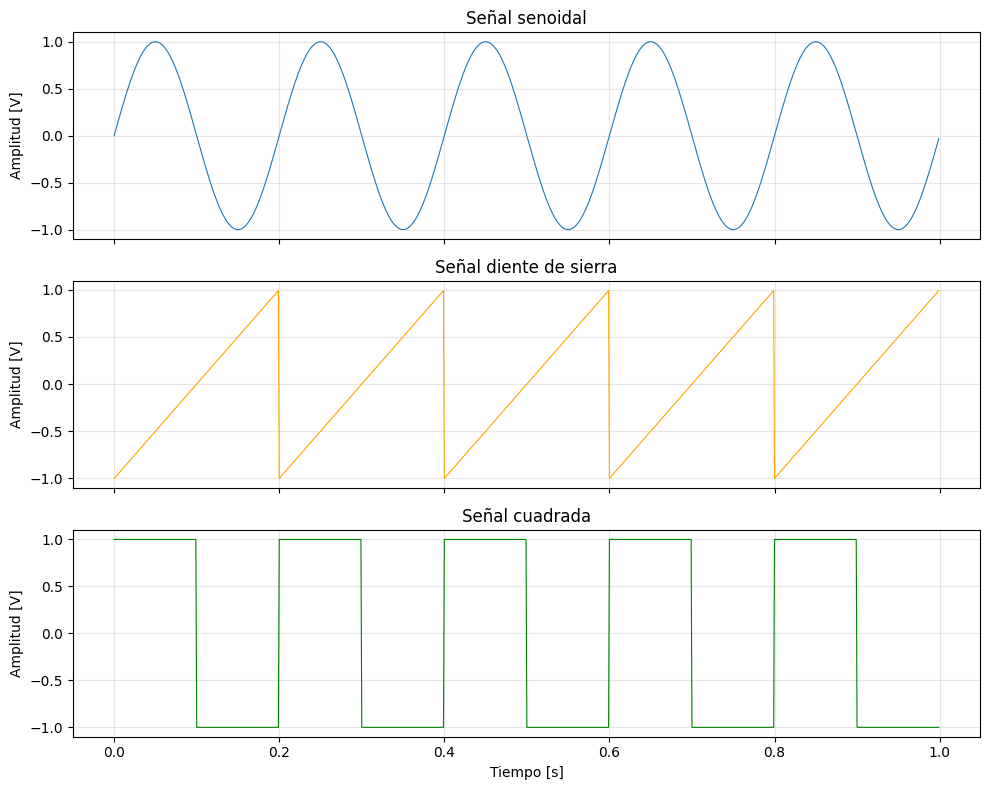

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    # Vector columna de tiempo
    tt = (np.arange(nn)/fs).reshape(-1,1)

    # Señal senoidal
    xx = vmax*np.sin(2*np.pi*ff*tt + ph) + dc    

    return tt, xx

def sawtooth(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    # Vector columna de tiempo
    tt = (np.arange(nn)/fs).reshape(-1,1)

    # Señal diente de sierra
    xx = vmax*signal.sawtooth(2*np.pi*ff*tt + ph) + dc    

    return tt, xx

def square(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    # Vector columna de tiempo
    tt = (np.arange(nn)/fs).reshape(-1,1)

    # Señal diente de sierra
    xx = vmax*signal.square(2*np.pi*ff*tt + ph) + dc    

    return tt, xx

# Senoidal
tt, xx_sine = mi_funcion_sen(1, 0, 5, 0, 1000, 1000)

# Diente de sierra
_, xx_sawtooth = sawtooth(1, 0, 5, 0, 1000, 1000)

# Cuadrada
_, xx_square = square(1, 0, 5, 0, 1000, 1000)


fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axs[0].plot(tt, xx_sine, linewidth=0.8)
axs[0].set_ylabel("Amplitud [V]")
axs[0].set_title("Señal senoidal")
axs[0].grid(True, alpha=0.3)

axs[1].plot(tt, xx_sawtooth, linewidth=0.8, color="orange")
axs[1].set_ylabel("Amplitud [V]")
axs[1].set_title("Señal diente de sierra")
axs[1].grid(True, alpha=0.3)

axs[2].plot(tt, xx_square, linewidth=0.8, color="green")
axs[2].set_ylabel("Amplitud [V]")
axs[2].set_title("Señal cuadrada")
axs[2].set_xlabel("Tiempo [s]")
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

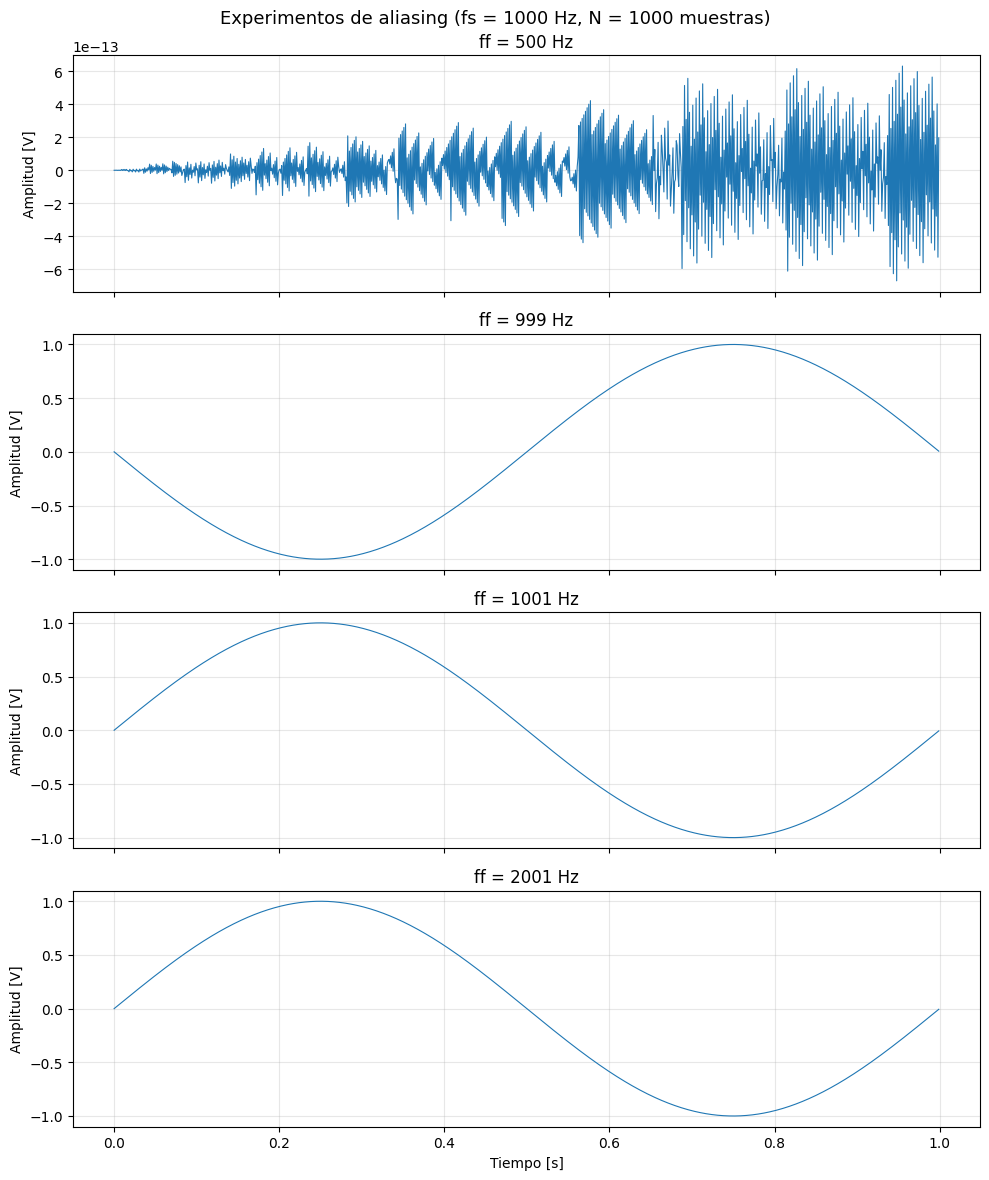

In [26]:
# Experimentos con aliasing (fs = 1000 Hz, N = 1000 muestras)
experimentos = [
    {"ff": 500,  "label": "ff = 500 Hz"},
    {"ff": 999,  "label": "ff = 999 Hz"},
    {"ff": 1001, "label": "ff = 1001 Hz"},
    {"ff": 2001, "label": "ff = 2001 Hz"},
]

fig2, axs2 = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

for ax, exp in zip(axs2, experimentos):
    tt_e, xx_e = mi_funcion_sen(vmax=1, dc=0, ff=exp["ff"], ph=0, nn=1000, fs=1000)
    ax.plot(tt_e, xx_e, linewidth=0.8)
    ax.set_ylabel("Amplitud [V]")
    ax.set_title(exp["label"])
    ax.grid(True, alpha=0.3)

axs2[-1].set_xlabel("Tiempo [s]")
fig2.suptitle("Experimentos de aliasing (fs = 1000 Hz, N = 1000 muestras)", fontsize=13)
plt.tight_layout()
plt.show()



### Explicación

1. Lo que se muestra en el gráfico es simplemente ruido, debido a que la muestra coincide con el cruce por cero de la señal y por lo tanto queda nula.
2. Justo por debajo de la frecuencia de muestreo, queda con una inversión de fase y 1 Hz de frecuencia.
3. Justo por arriba de la frecuencia de muestreo, queda como una señal de 1 Hz.
4. Queda por arriba del segundo armónico de la frecuencia de muestreo, queda como una señal de 1 Hz.

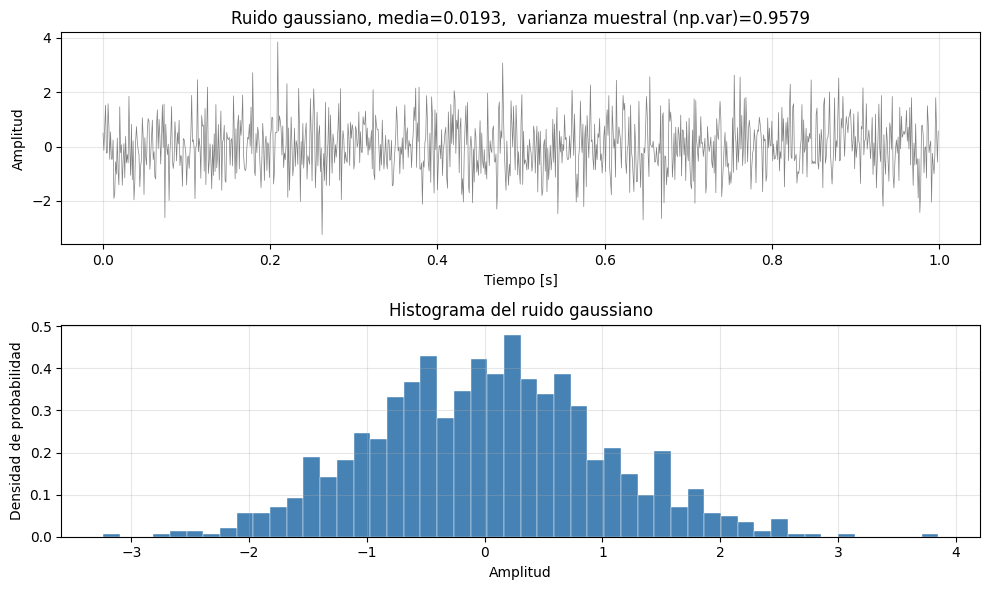

In [27]:
# Configuro semilla del generador, para la reproducibilidad
np.random.seed(42)
nn_r = 1000
fs_r = 1000
tt_r = (np.arange(nn_r) / fs_r).reshape(-1, 1)

# Ruido normalmente distribuido: media=0, varianza=1 (escala=sigma=1)
ruido = np.random.normal(loc=0, scale=1, size=(nn_r, 1))

fig3, axs3 = plt.subplots(2, 1, figsize=(10, 6))

axs3[0].plot(tt_r, ruido, linewidth=0.5, color='gray')
axs3[0].set_ylabel("Amplitud")
axs3[0].set_title(
    f"Ruido gaussiano, media={np.mean(ruido):.4f},  varianza muestral (np.var)={np.var(ruido):.4f}"
)
axs3[0].set_xlabel("Tiempo [s]")
axs3[0].grid(True, alpha=0.3)

axs3[1].hist(ruido, bins=50, density=True, color='steelblue', edgecolor='white', linewidth=0.3)
axs3[1].set_xlabel("Amplitud")
axs3[1].set_ylabel("Densidad de probabilidad")
axs3[1].set_title("Histograma del ruido gaussiano")
axs3[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

  Potencia señal teórica : 1.0000 W
  Potencia señal np.var  : 1.0000 W
  Potencia ruido teórica : 0.1000 W  (100.0 mW)
  Potencia ruido np.var  : 0.0994 W
  SNR definida           : 10 dB
  SNR medida (muestral)  : 10.03 dB


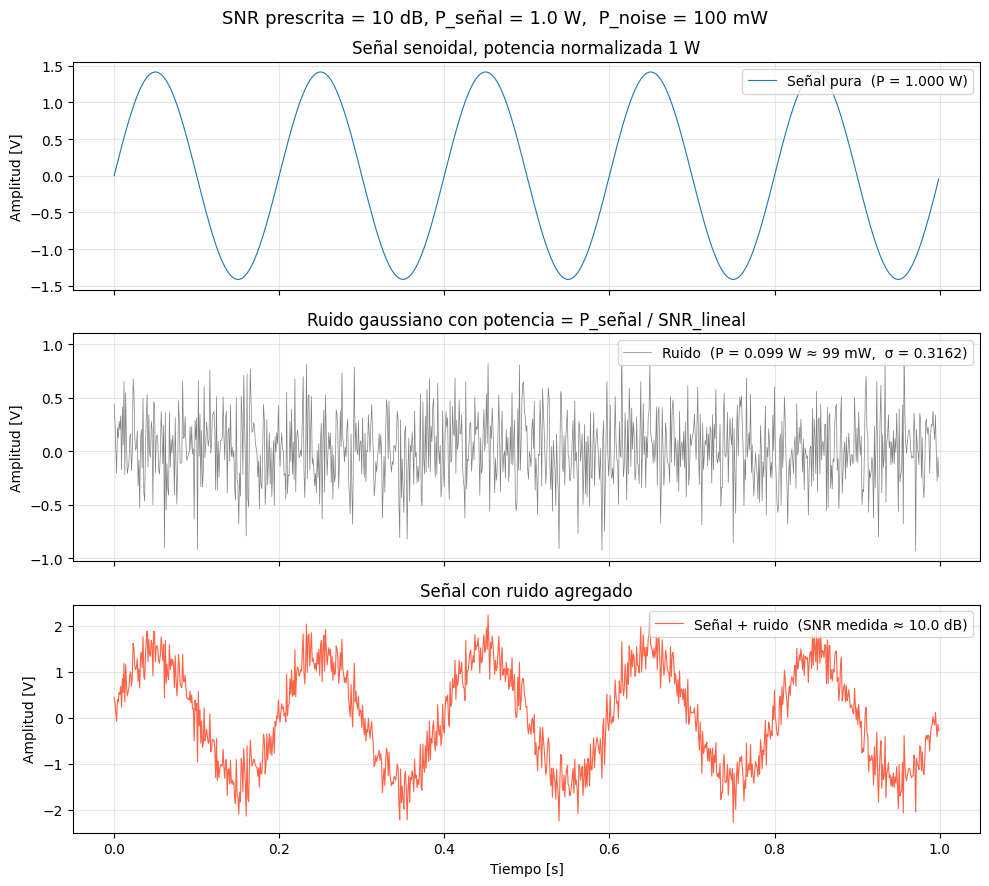

In [28]:
SNR_dB     = 10                         # Relación señal-ruido en decibeles
SNR_lineal = 10 ** (SNR_dB / 10)        # SNR en veces
P_signal   = 1.0                        # Potencia de señal, 1 W normalizado
A_signal   = np.sqrt(2 * P_signal)      # Amplitud de la señal
P_noise    = P_signal / SNR_lineal      # Potencia del ruido, 0.1 W = 100 mW
sigma      = np.sqrt(P_noise)           # Desviación estándar del ruido

# Senoidal pura, señal de ruido y senoidal ruidosa
tt_s, xx_sen = mi_funcion_sen(vmax=A_signal, dc=0, ff=5, ph=0, nn=1000, fs=1000)
ruido_snr    = np.random.normal(loc=0, scale=sigma, size=xx_sen.shape)
xx_ruidosa   = xx_sen + ruido_snr

# Verificación con varianza muestral
P_sen_med  = np.var(xx_sen)
P_noise_med = np.var(ruido_snr)
SNR_med_dB  = 10 * np.log10(P_sen_med / P_noise_med)

print(f"  Potencia señal teórica : {P_signal:.4f} W")
print(f"  Potencia señal np.var  : {P_sen_med:.4f} W")
print(f"  Potencia ruido teórica : {P_noise:.4f} W  ({P_noise*1000:.1f} mW)")
print(f"  Potencia ruido np.var  : {P_noise_med:.4f} W")
print(f"  SNR definida           : {SNR_dB} dB")
print(f"  SNR medida (muestral)  : {SNR_med_dB:.2f} dB")

fig4, axs4 = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

axs4[0].plot(tt_s, xx_sen, linewidth=0.8,
             label=f"Señal pura  (P = {P_sen_med:.3f} W)")
axs4[0].set_ylabel("Amplitud [V]")
axs4[0].set_title("Señal senoidal, potencia normalizada 1 W")
axs4[0].legend(loc='upper right')
axs4[0].grid(True, alpha=0.3)

axs4[1].plot(tt_s, ruido_snr, linewidth=0.5, color='gray',
             label=f"Ruido  (P = {P_noise_med:.3f} W ≈ {P_noise_med*1000:.0f} mW,  σ = {sigma:.4f})")
axs4[1].set_ylabel("Amplitud [V]")
axs4[1].set_title("Ruido gaussiano con potencia = P_señal / SNR_lineal")
axs4[1].legend(loc='upper right')
axs4[1].grid(True, alpha=0.3)

axs4[2].plot(tt_s, xx_ruidosa, linewidth=0.8, color='tomato',
             label=f"Señal + ruido  (SNR medida ≈ {SNR_med_dB:.1f} dB)")
axs4[2].set_ylabel("Amplitud [V]")
axs4[2].set_title("Señal con ruido agregado")
axs4[2].set_xlabel("Tiempo [s]")
axs4[2].legend(loc='upper right')
axs4[2].grid(True, alpha=0.3)

fig4.suptitle(
    f"SNR prescrita = {SNR_dB} dB, P_señal = {P_signal} W,  P_noise = {P_noise*1000:.0f} mW",
    fontsize=13
)
plt.tight_layout()
plt.show()


### Notas
La varianza de la variable y la potencia de la señal son las mismas debido a que se normaliza la señal y el valor medio de la señal es cero. La discrepancia es debido a un error de estimación muestral, ya que no hay infinitas muestras.